In [1]:
import io
import os
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path
import openslide

#import ecalic.cmsStyle

import pandas as pd

required_modules = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "PIL": "pillow",
    "pydicom": "pydicom",
    "tifffile": "tifffile",
}

for module_name, package_name in required_modules.items():
    try:
        __import__(module_name)
    except ImportError:
        print(f"{package_name} not found. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

In [2]:
from pdigy import pdigy, pdigyDecoder
from pydicom.dataset import Dataset, FileDataset, FileMetaDataset
from pydicom.encaps import encapsulate
from pydicom.uid import (
    JPEGBaseline8Bit,
    PYDICOM_IMPLEMENTATION_UID,
    VLWholeSlideMicroscopyImageStorage,
    generate_uid,
    )

In [3]:
from test_helpers import (
    ensure_rgb_uint8, crop_white_border,
    save_lossless_tiff, save_lossless_svs,
    iter_padded_tiles, encode_jpeg_tile, encode_j2k_lossless_tile,
    save_tiled_dicom, save_lossless_dicom,
    reconstruct_tissue_only, time_fn, make_bench_tasks,
    _mb, _row, _bench,
)


The TCGA database files cannot be distributed by a third party but you can access the following example file from https://portal.gdc.cancer.gov/files/0b4b695b-b7e5-40ce-b2a7-d17fdf540522

In [4]:
# Check if the test sample file exists, if not download it
image_path = '../test_sample/TCGA-HZ-7924-01Z-00-DX1.d73d1606-bda1-441b-ab00-69645fae6553.svs'

if not os.path.exists(image_path):
    print(f"File not found: {image_path}")
    print("Downloading from GDC Portal...")
    
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(image_path), exist_ok=True)
    
    # Download the file
    download_url = "https://api.gdc.cancer.gov/data/0b4b695b-b7e5-40ce-b2a7-d17fdf540522"
    subprocess.check_call(["wget", "-O", image_path, download_url])
    print(f"Downloaded successfully to {image_path}")
else:
    print(f"File already exists: {image_path}")

File already exists: ../test_sample/TCGA-HZ-7924-01Z-00-DX1.d73d1606-bda1-441b-ab00-69645fae6553.svs


In [5]:
image_path = '../test_sample/TCGA-HZ-7924-01Z-00-DX1.d73d1606-bda1-441b-ab00-69645fae6553.svs'
example_path = "PDigyExample.xlsx"

JPEG_QUALITY = 95  # shared quality for all lossy formats

encoding_configs = [
    {
        "label": "with_whitespace",
        "pdigy_remove_whitespace": False,
        "output_path": "out_with_whitespace",
        "encoder_kwargs": {
            "patch_size": 512,
            "patch_format": "JPEG",
            "patch_jpeg_quality": JPEG_QUALITY,
        },
    },
    {
        "label": "without_whitespace",
        "pdigy_remove_whitespace": True,
        "output_path": "out_without_whitespace",
        "encoder_kwargs": {
            "patch_size": 512,
            "patch_format": "JPEG",
            "patch_jpeg_quality": JPEG_QUALITY,
            "whitespace_preview_size": 16,
            "whitespace_mean_intensity_threshold": 0.94,
            "whitespace_std_intensity_threshold": 0.015,
        },
    },
    {
        "label": "lossless",
        "pdigy_remove_whitespace": False,
        "output_path": "out_lossless",
        "encoder_kwargs": {
            "patch_size": 512,
            "patch_format": "JPEG2000",
        },
    },
    {
        "label": "lossless_zero_compressed",
        "pdigy_remove_whitespace": True,
        "output_path": "out_lossless_zero_compressed",
        "encoder_kwargs": {
            "patch_size": 512,
            "patch_format": "JPEG2000",
            "whitespace_preview_size": 16,
            "whitespace_mean_intensity_threshold": 0.94,
            "whitespace_std_intensity_threshold": 0.015,
        },
    },
]


In [6]:

patch_size = encoding_configs[0]["encoder_kwargs"]["patch_size"]

# I read straight from SVS so every format encodes the exact same pixels
_slide = openslide.OpenSlide(image_path)
export_image = crop_white_border(_slide.read_region((0, 0), 0, _slide.level_dimensions[0]).convert("RGB"))
_slide.close()

export_dir = Path("converted_large_images") / "exported"
export_dir.mkdir(parents=True, exist_ok=True)

tiff_path           = export_dir / "image.tiff"
svs_path            = export_dir / "image.svs"
dicom_path          = export_dir / "image.dcm"
dicom_lossless_path = export_dir / "image_lossless.dcm"

save_lossless_tiff(export_image,  tiff_path,           tile_size=patch_size)
save_lossless_svs(export_image,   svs_path,            tile_size=patch_size)
save_tiled_dicom(export_image,    dicom_path,          tile_size=patch_size, jpeg_quality=JPEG_QUALITY)
save_lossless_dicom(export_image, dicom_lossless_path, tile_size=patch_size)

comparison_rows = []
generated_files = {}

for config in encoding_configs:
    pdigy_file = pdigy(
        image=export_image,
        meta_path=example_path,
        remove_whitespace=config["pdigy_remove_whitespace"],
        **config["encoder_kwargs"],
    )
    pdigy_file.save_to_file(config["output_path"])
    file_path = f"{config['output_path']}.pdigy"
    generated_files[config["label"]] = file_path

    comparison_rows.append({
        "variant":                 config["label"],
        "file_path":               file_path,
        "size_bytes":              os.path.getsize(file_path),
        "patch_size":              pdigy_file.patch_size,
        "patch_format":            pdigy_file.patch_format,
        "lzma":                    pdigy_file.compression,
        "preview_patch_size":      pdigy_file.whitespace_preview_size,
        "total_patch_slots":       int(pdigy_file.patch_modes.size),
        "full_resolution_patches": int((pdigy_file.patch_modes == 1).sum()),
        "preview_patches":         int((pdigy_file.patch_modes == 2).sum()),
    })

comparison_df = pd.DataFrame(comparison_rows)
baseline_size = comparison_df["size_bytes"].iloc[0]
comparison_df["bytes_saved"]   = baseline_size - comparison_df["size_bytes"]
comparison_df["percent_saved"] = (comparison_df["bytes_saved"] / baseline_size * 100).round(4)

decoders = {c["label"]: pdigyDecoder(generated_files[c["label"]]) for c in encoding_configs}

format_rows = [
    {"format": "TIFF",  "variant": "exported", "file_path": str(tiff_path),           "size_bytes": tiff_path.stat().st_size},
    {"format": "SVS",   "variant": "exported", "file_path": str(svs_path),            "size_bytes": svs_path.stat().st_size},
    {"format": "DICOM", "variant": "lossy",    "file_path": str(dicom_path),          "size_bytes": dicom_path.stat().st_size},
    {"format": "DICOM", "variant": "lossless", "file_path": str(dicom_lossless_path), "size_bytes": dicom_lossless_path.stat().st_size},
    *[
        {"format": "PDIGY", "variant": c["label"],
         "file_path": generated_files[c["label"]], "size_bytes": os.path.getsize(generated_files[c["label"]])}
        for c in encoding_configs
    ],
]

format_comparison_df = pd.DataFrame(format_rows)
format_comparison_df["size_mb"] = (format_comparison_df["size_bytes"] / 1024**2).round(2)
format_comparison_df


Maximum pixel value is estimated to be: 255
img.shape (27493, 24940, 3)
pass: 2646  fail: 0  efficiency: 100.00%
54 49
Maximum pixel value is estimated to be: 255
img.shape (27493, 24940, 3)
pass: 1388  fail: 1258  efficiency: 52.46%
54 49
Maximum pixel value is estimated to be: 255
img.shape (27493, 24940, 3)
pass: 2646  fail: 0  efficiency: 100.00%
54 49
Maximum pixel value is estimated to be: 255
img.shape (27493, 24940, 3)
pass: 1388  fail: 1258  efficiency: 52.46%
54 49


,format,variant,file_path,size_bytes,size_mb
0,TIFF,exported,converted_large_images/exported/image.tiff,653413707,623.14
1,SVS,exported,converted_large_images/exported/image.svs,653413707,623.14
2,DICOM,lossy,converted_large_images/exported/image.dcm,244035410,232.73
3,DICOM,lossless,converted_large_images/exported/image_lossless...,601469940,573.61
4,PDIGY,with_whitespace,out_with_whitespace.pdigy,243900756,232.60
5,PDIGY,without_whitespace,out_without_whitespace.pdigy,212938700,203.07
6,PDIGY,lossless,out_lossless.pdigy,601434577,573.57
7,PDIGY,lossless_zero_compressed,out_lossless_zero_compressed.pdigy,473883680,451.93


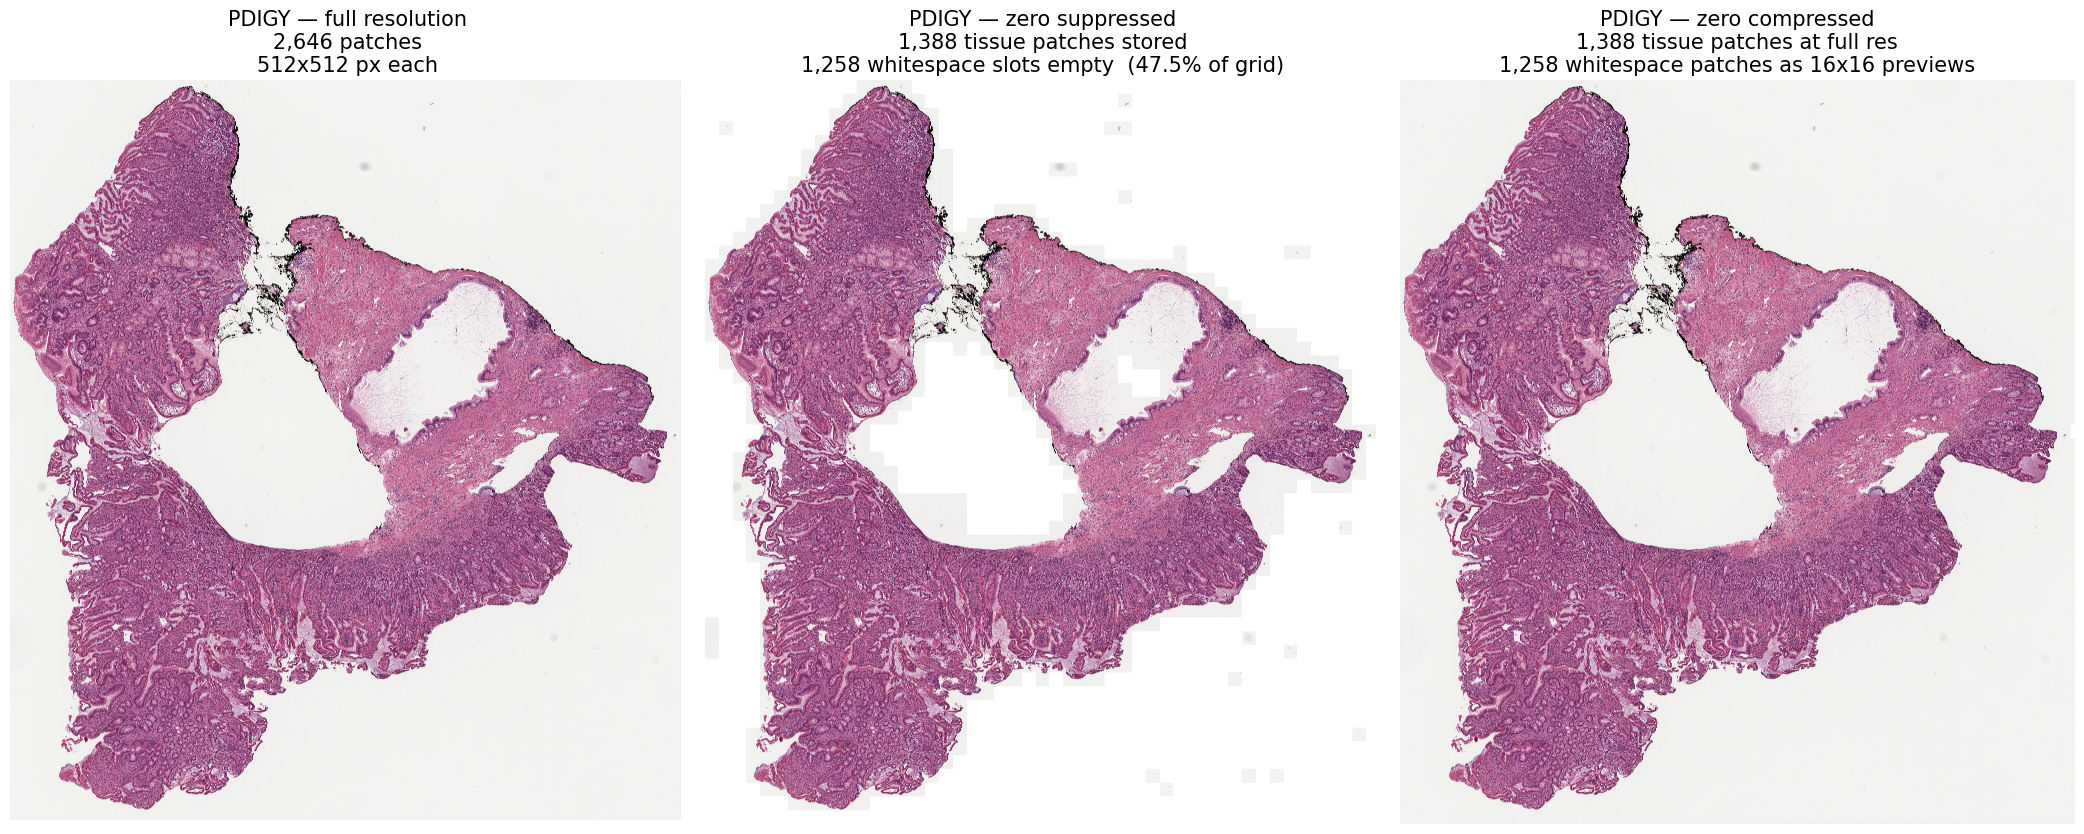

In [7]:
_n_full   = int(comparison_df.loc[comparison_df["variant"] == "with_whitespace",   "full_resolution_patches"].iloc[0])
_n_tissue = int(comparison_df.loc[comparison_df["variant"] == "without_whitespace", "full_resolution_patches"].iloc[0])
_n_prev   = int(comparison_df.loc[comparison_df["variant"] == "without_whitespace", "preview_patches"].iloc[0])
_n_total  = _n_tissue + _n_prev

fig, axes = plt.subplots(1, 3, figsize=(21, 8))

axes[0].imshow(decoders["with_whitespace"].full_image)
axes[0].set_title(
    f"PDIGY — full resolution\n"
    f"{_n_full:,} patches\n"
    f"512x512 px each",
    fontsize=15,
)
axes[0].axis("off")

axes[1].imshow(reconstruct_tissue_only(decoders["without_whitespace"]))
axes[1].set_title(
    f"PDIGY — zero suppressed\n"
    f"{_n_tissue:,} tissue patches stored\n"
    f"{_n_prev:,} whitespace slots empty  ({_n_prev / _n_total * 100:.1f}% of grid)",
    fontsize=15,
)
axes[1].axis("off")

axes[2].imshow(decoders["without_whitespace"].full_image)
axes[2].set_title(
    f"PDIGY — zero compressed\n"
    f"{_n_tissue:,} tissue patches at full res\n"
    f"{_n_prev:,} whitespace patches as 16x16 previews",
    fontsize=15,
)
axes[2].axis("off")

plt.tight_layout()
plt.show()


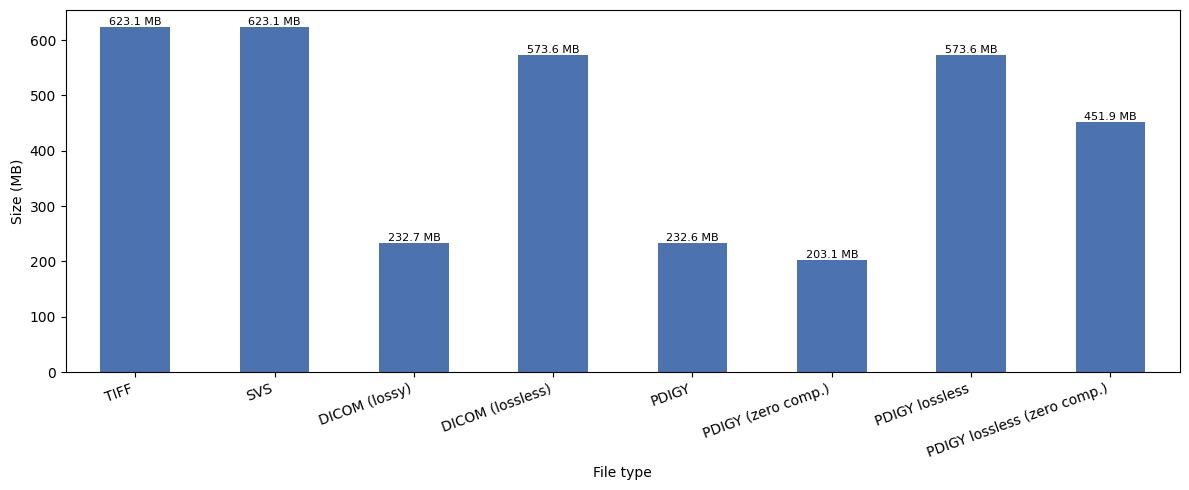

,format,variant,size_mb,file_path
0,TIFF,exported,623.14,converted_large_images/exported/image.tiff
1,SVS,exported,623.14,converted_large_images/exported/image.svs
2,DICOM,lossy,232.73,converted_large_images/exported/image.dcm
3,DICOM,lossless,573.61,converted_large_images/exported/image_lossless...
4,PDIGY,with_whitespace,232.60,out_with_whitespace.pdigy
5,PDIGY,without_whitespace,203.07,out_without_whitespace.pdigy
6,PDIGY,lossless,573.57,out_lossless.pdigy
7,PDIGY,lossless_zero_compressed,451.93,out_lossless_zero_compressed.pdigy


In [8]:
_VARIANT_LABELS = {
    ("PDIGY", "with_whitespace"):          "PDIGY",
    ("PDIGY", "without_whitespace"):       "PDIGY (zero comp.)",
    ("PDIGY", "lossless"):                 "PDIGY lossless",
    ("PDIGY", "lossless_zero_compressed"): "PDIGY lossless (zero comp.)",
}

plot_df = format_comparison_df.copy()
plot_df["File type"] = plot_df.apply(
    lambda r: _VARIANT_LABELS.get(
        (r["format"], r["variant"]),
        r["format"] if r["variant"] == "exported" else f"{r['format']} ({r['variant']})",
    ),
    axis=1,
)
ax = plot_df.set_index("File type")["size_mb"].plot(
    kind="bar",
    figsize=(12, 5),
    color="#4C72B0",
)
ax.set_ylabel("Size (MB)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f MB", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

format_comparison_df[["format", "variant", "size_mb", "file_path"]]


Benchmarking TIFF...
Benchmarking SVS...
Benchmarking DICOM lossy...
Benchmarking DICOM lossless...
Benchmarking PDIGY...
Benchmarking PDIGY (zero compressed)...
Benchmarking PDIGY lossless...
Benchmarking PDIGY lossless (zero compressed)...


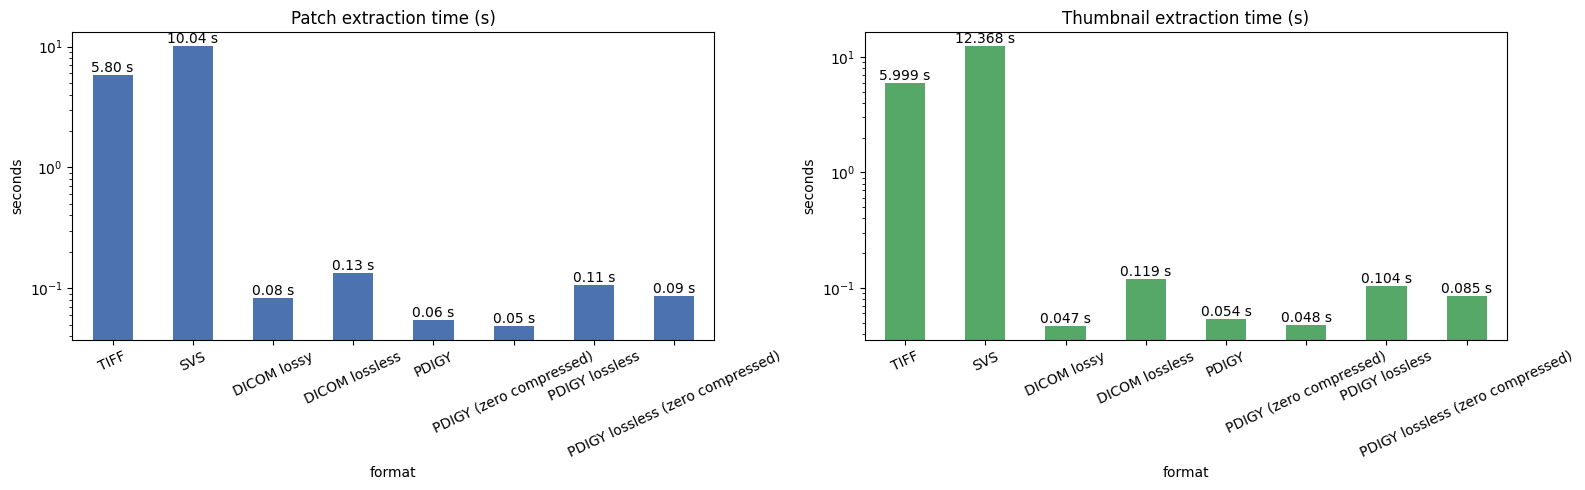

,format,patch_count,patch_time_s,thumbnail_time_s
0,TIFF,2646,5.802,5.999
1,SVS,2646,10.043,12.368
2,DICOM lossy,2646,0.083,0.047
3,DICOM lossless,2646,0.134,0.119
4,PDIGY,2646,0.055,0.054
5,PDIGY (zero compressed),1388,0.049,0.048
6,PDIGY lossless,2646,0.106,0.104
7,PDIGY lossless (zero compressed),1388,0.086,0.085


In [9]:
BENCHMARK_REPEATS = 5

bench_tasks = make_bench_tasks(
    tiff_path, svs_path, dicom_path, dicom_lossless_path,
    patch_size, generated_files,
)

bench_rows = []
for fmt, patch_fn, thumb_fn in bench_tasks:
    print(f'Benchmarking {fmt}...')
    pt, patches = time_fn(patch_fn, repeats=BENCHMARK_REPEATS)
    tt, _       = time_fn(thumb_fn, repeats=BENCHMARK_REPEATS)
    bench_rows.append({
        'format':           fmt,
        'patch_count':      len(patches),
        'patch_time_s':     round(pt, 3),
        'thumbnail_time_s': round(tt, 3),
    })

bench_df = pd.DataFrame(bench_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bench_df.set_index('format')['patch_time_s'].plot(
    kind='bar', ax=axes[0], color='#4C72B0', title='Patch extraction time (s)')
axes[0].set_ylabel('seconds')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.2f s')

bench_df.set_index('format')['thumbnail_time_s'].plot(
    kind='bar', ax=axes[1], color='#55A868', title='Thumbnail extraction time (s)')
axes[1].set_ylabel('seconds')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.3f s')

for ax in axes:
    ax.tick_params(axis='x', rotation=25)

axes[0].set_yscale('log')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

bench_df


In [10]:
image_path   = '../test_sample/TCGA-HZ-7924-01Z-00-DX1.d73d1606-bda1-441b-ab00-69645fae6553.svs'
example_path = "PDigyExample.xlsx"
JPEG_QUALITY = 95  # lossy but not embarrassingly so

encoding_configs = [
    {
        "label": "with_whitespace",
        "pdigy_remove_whitespace": False,
        "output_path": "out_with_whitespace",
        "encoder_kwargs": {
            "patch_size": 512,
            "patch_format": "JPEG",
            "patch_jpeg_quality": JPEG_QUALITY,
        },
    },
    {
        "label": "without_whitespace",
        "pdigy_remove_whitespace": True,
        "output_path": "out_without_whitespace",
        "encoder_kwargs": {
            "patch_size": 512,
            "patch_format": "JPEG",
            "patch_jpeg_quality": JPEG_QUALITY,
            "whitespace_preview_size": 16,
            "whitespace_mean_intensity_threshold": 0.94,
            "whitespace_std_intensity_threshold": 0.015,
        },
    },
    {
        "label": "lossless",
        "pdigy_remove_whitespace": False,
        "output_path": "out_lossless",
        "encoder_kwargs": {
            "patch_size": 512,
            "patch_format": "JPEG2000",
        },
    },
    {
        "label": "lossless_zero_compressed",
        "pdigy_remove_whitespace": True,
        "output_path": "out_lossless_zero_compressed",
        "encoder_kwargs": {
            "patch_size": 512,
            "patch_format": "JPEG2000",
            "whitespace_preview_size": 16,
            "whitespace_mean_intensity_threshold": 0.94,
            "whitespace_std_intensity_threshold": 0.015,
        },
    },
]


In [11]:
# How much does LZMA actually save on already-JPEG-compressed patch data?
import pickle, lzma, io

dec = pdigyDecoder(generated_files["without_whitespace"])

patch_payload = {
    "patches":              dec.patches,
    "filter_map":           dec.filter_map,
    "patch_modes":          dec.patch_modes,
    "patch_size":           dec.patch_size,
    "whitespace_preview_size": dec.whitespace_preview_size,
}

raw_bytes      = pickle.dumps(patch_payload)
compressed     = lzma.compress(raw_bytes)

raw_mb         = len(raw_bytes)      / 1024**2
compressed_mb  = len(compressed)     / 1024**2
delta_mb       = raw_mb - compressed_mb
ratio          = len(compressed) / len(raw_bytes)

print(f"Pickle (raw):       {raw_mb:.2f} MB")
print(f"LZMA compressed:    {compressed_mb:.2f} MB")
print(f"Saved:              {delta_mb:.2f} MB  ({(1-ratio)*100:.1f}%)")
print(f"Compression ratio:  {ratio:.4f}x  (>1 means LZMA expands the data)")

Pickle (raw):       202.93 MB
LZMA compressed:    199.83 MB
Saved:              3.10 MB  (1.5%)
Compression ratio:  0.9847x  (>1 means LZMA expands the data)
